# Multi-Condition Telemetry Comparison

14 workloads collected on H100 SXM5-80GB at DCGM 10Hz. Steady-state only, truncated to 300s.

**Red** = training + evasion (things we want to detect)  
**Blue** = inference + baseline (benign reference)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

DATA_DIR = Path('../data')
PLOT_DIR = Path('../plots')
PLOT_DIR.mkdir(exist_ok=True)

CONDITIONS = {
    'T1': ('t1_telemetry.csv', 'Large DDP (3.37B)',       'Training'),
    'T2': ('t2_telemetry.csv', 'Small DDP (136M)',        'Training'),
    'T3': ('t3_telemetry.csv', 'Grad Accum (16x)',        'Training'),
    'T4': ('t4_telemetry.csv', 'Pipeline Parallel',       'Training'),
    'T5': ('t5_telemetry.csv', 'Grad Checkpoint (6.7B)',  'Training'),
    'T6': ('t6_telemetry.csv', 'FSDP / ZeRO-3',          'Training'),
    'E2': ('e2_telemetry.csv', 'Cover Traffic',           'Evasion'),
    'E3': ('e3_telemetry.csv', 'Intermittent Training',   'Evasion'),
    'E4': ('e4_telemetry.csv', 'PCIe-Only Allreduce',     'Evasion'),
    'E5': ('e5_telemetry.csv', 'Smoothed Allreduce',      'Evasion'),
    'I2': ('i2_telemetry.csv', 'Streaming Inference',     'Inference'),
    'I3': ('i3_telemetry.csv', 'vLLM High-Throughput',    'Inference'),
    'I4': ('i4_telemetry.csv', 'Speculative Decoding',    'Inference'),
    'B1': ('b1_telemetry.csv', 'Idle + Model Loaded',     'Baseline'),
}

# Two-section ordering: flag (training+evasion) then benign (inference+baseline)
TOP_ORDER = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'E2', 'E3', 'E4', 'E5']
BOT_ORDER = ['I2', 'I3', 'I4', 'B1']
CONDITION_ORDER = TOP_ORDER + BOT_ORDER

# Binary palette: red = flag, blue = benign. Two shades per side.
SHADE = {
    'Training':  '#b03a2e',
    'Evasion':   '#e74c3c',
    'Inference': '#1a5276',
    'Baseline':  '#5dade2',
}
COLORS = {code: SHADE[CONDITIONS[code][2]] for code in CONDITIONS}

SIGNALS = {
    'power_w':        ('Power (W)',         None),
    'sm_active':      ('SM Active',         (0, 1.05)),
    'tensor_active':  ('Tensor Active',     (0, 1.05)),
    'nvlink_tx_gb_s': ('NVLink TX (GB/s)',  None),
    'mem_used_gib':   ('Memory Used (GiB)', None),
}

MAX_DURATION = 300  # truncate all conditions to 300s

print('Setup complete.')

Setup complete.


In [2]:
dfs = {}
for code, (fname, label, cat) in CONDITIONS.items():
    path = DATA_DIR / fname
    if not path.exists():
        print(f'  SKIP {code}: {path} not found')
        continue
    df = pd.read_csv(path)
    if code == 'E3':
        mask = df['phase'].isin(['steady', 'sleep'])
    else:
        mask = df['phase'] == 'steady'
    steady = df[mask].copy()
    if len(steady) == 0:
        print(f'  SKIP {code}: no steady-state rows')
        continue
    steady['rel_time'] = steady['timestamp'] - steady['timestamp'].min()
    steady = steady[steady['rel_time'] <= MAX_DURATION].copy()
    steady['nvlink_tx_gb_s'] = steady['nvlink_tx_bytes_s'] / 1e9
    steady['nvlink_rx_gb_s'] = steady['nvlink_rx_bytes_s'] / 1e9
    steady['mem_used_gib'] = steady['mem_used_mib'] / 1024
    steady['condition'] = code
    steady['label'] = label
    steady['category'] = cat
    dfs[code] = steady
    print(f'  {code}: {len(steady):>6,} rows, {steady["rel_time"].max():.0f}s')

all_data = pd.concat(dfs.values(), ignore_index=True)
print(f'\nTotal: {len(all_data):,} rows across {len(dfs)} conditions')

  T1: 21,544 rows, 270s
  T2: 21,496 rows, 270s


  T3: 21,216 rows, 265s


  T4: 23,976 rows, 300s


  T5: 21,496 rows, 270s
  T6: 21,584 rows, 270s


  E2: 20,888 rows, 262s


  E3: 23,928 rows, 300s


  E4: 23,936 rows, 300s


  E5: 23,880 rows, 300s


  I2: 23,944 rows, 300s
  I3: 21,496 rows, 270s


  I4: 21,872 rows, 274s
  B1: 19,776 rows, 247s

Total: 311,032 rows across 14 conditions


## Summary Table

In [3]:
summary_cols = ['power_w', 'sm_active', 'tensor_active', 'nvlink_tx_gb_s', 'mem_used_gib']
summary_labels = ['Power (W)', 'SM Active', 'Tensor Active', 'NVLink TX (GB/s)', 'Mem Used (GiB)']

rows = []
for code in CONDITION_ORDER:
    if code not in dfs:
        continue
    df = dfs[code]
    _, label, cat = CONDITIONS[code]
    row = {'Condition': f'{code}: {label}', 'Category': cat}
    for col, lbl in zip(summary_cols, summary_labels):
        m, s = df[col].mean(), df[col].std()
        if col in ('sm_active', 'tensor_active'):
            row[lbl] = f'{m:.3f} \u00b1 {s:.3f}'
        elif col == 'nvlink_tx_gb_s':
            row[lbl] = f'{m:.2f} \u00b1 {s:.2f}'
        else:
            row[lbl] = f'{m:.0f} \u00b1 {s:.0f}'
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,Condition,Category,Power (W),SM Active,Tensor Active,NVLink TX (GB/s),Mem Used (GiB)
0,T1: Large DDP (3.37B),Training,688 ± 6,0.858 ± 0.042,0.474 ± 0.131,18.21 ± 11.75,67 ± 0
1,T2: Small DDP (136M),Training,547 ± 22,0.638 ± 0.044,0.194 ± 0.015,8.92 ± 0.97,12 ± 0
2,T3: Grad Accum (16x),Training,689 ± 11,0.877 ± 0.064,0.583 ± 0.081,1.50 ± 6.11,69 ± 0
3,T4: Pipeline Parallel,Training,336 ± 81,0.375 ± 0.232,0.134 ± 0.082,0.56 ± 0.39,16 ± 3
4,T5: Grad Checkpoint (6.7B),Training,685 ± 4,0.858 ± 0.044,0.483 ± 0.123,15.19 ± 8.44,70 ± 0
5,T6: FSDP / ZeRO-3,Training,186 ± 92,0.090 ± 0.241,0.057 ± 0.163,5.04 ± 13.89,32 ± 0
6,E2: Cover Traffic,Evasion,408 ± 278,0.445 ± 0.422,0.242 ± 0.256,12.16 ± 16.54,47 ± 20
7,E3: Intermittent Training,Evasion,520 ± 255,0.603 ± 0.394,0.332 ± 0.243,12.81 ± 12.93,63 ± 16
8,E4: PCIe-Only Allreduce,Evasion,176 ± 88,0.091 ± 0.235,0.045 ± 0.146,0.00 ± 0.00,64 ± 0
9,E5: Smoothed Allreduce,Evasion,625 ± 8,0.732 ± 0.223,0.410 ± 0.216,24.70 ± 14.40,74 ± 0


## 1. Signal Distributions
Two variants: violin plots (show distribution shape — bimodality in E3) and dot plots (compact mean \u00b1 std).

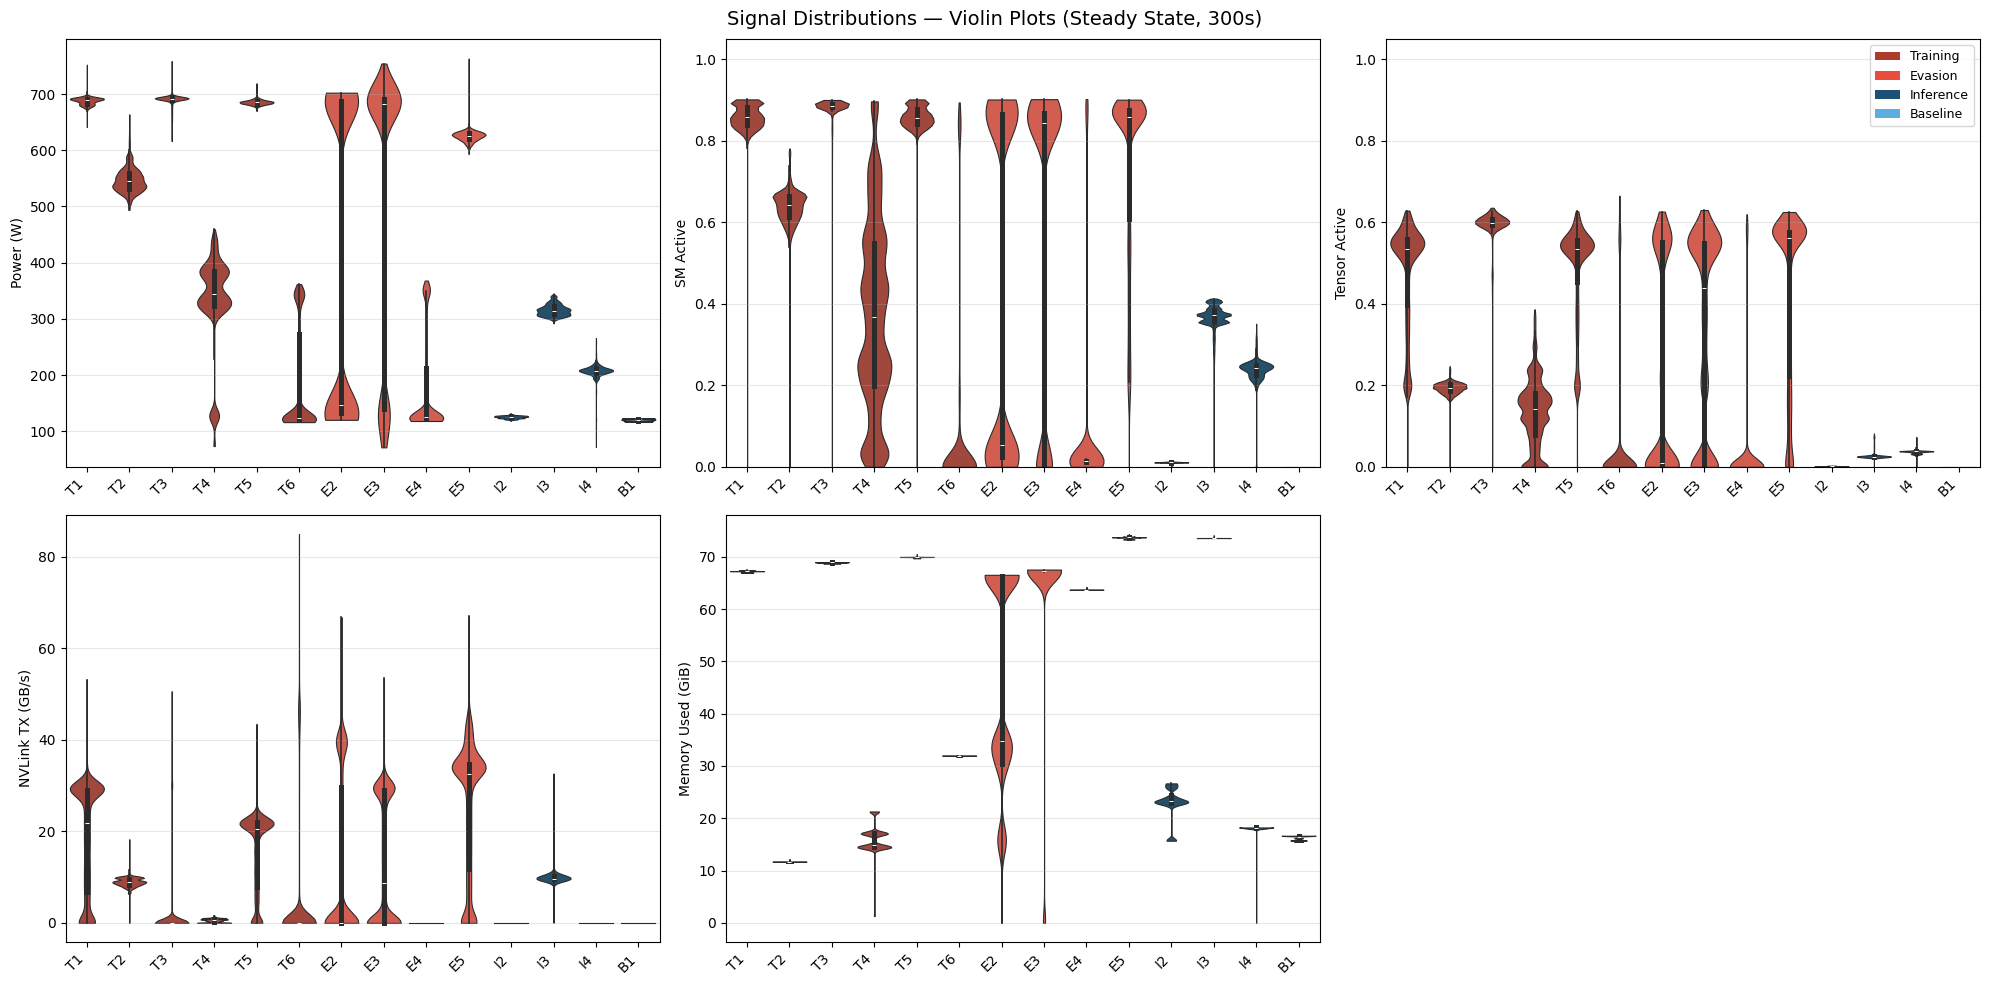

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes_flat = axes.flatten()

palette = {code: COLORS[code] for code in CONDITION_ORDER if code in dfs}
for i, (col, (ylabel, ylim)) in enumerate(SIGNALS.items()):
    ax = axes_flat[i]
    sns.violinplot(
        data=all_data, x='condition', y=col, order=CONDITION_ORDER,
        palette=palette, ax=ax, inner='box', linewidth=0.8, cut=0, scale='width',
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    if ylim:
        ax.set_ylim(ylim)
    ax.set_xticklabels(CONDITION_ORDER, rotation=45, ha='right')

axes_flat[5].set_visible(False)

legend_elements = [Patch(facecolor=SHADE[cat], label=cat) for cat in SHADE]
axes_flat[2].legend(handles=legend_elements, loc='upper right', fontsize=9)

fig.suptitle('Signal Distributions — Violin Plots (Steady State, 300s)', fontsize=14)
fig.tight_layout()
fig.savefig(PLOT_DIR / '01a_distributions_violin.png', dpi=150, bbox_inches='tight')
plt.show()

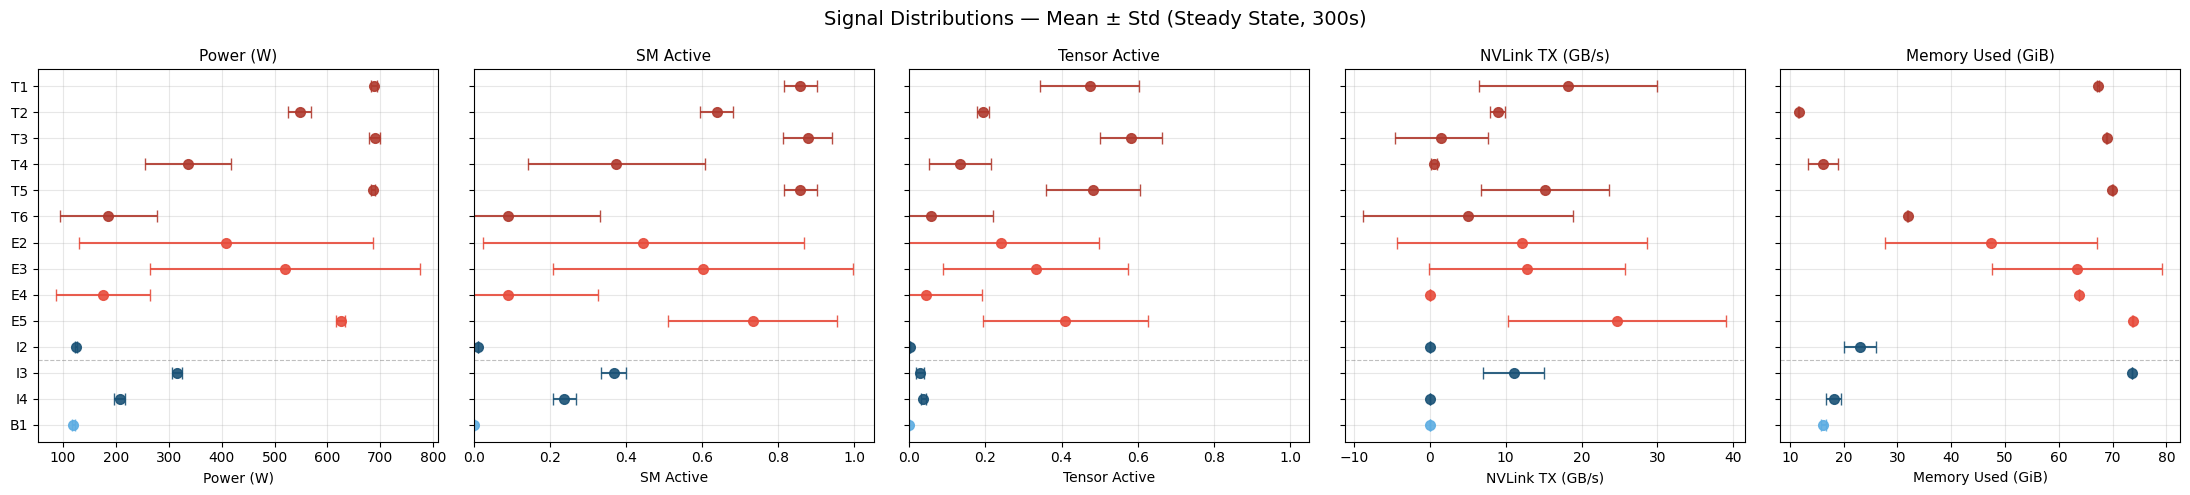

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

y_labels = list(reversed(CONDITION_ORDER))

for ax, (col, (xlabel, xlim)) in zip(axes, SIGNALS.items()):
    for j, code in enumerate(y_labels):
        if code not in dfs:
            continue
        df = dfs[code]
        m, s = df[col].mean(), df[col].std()
        ax.errorbar(m, j, xerr=s, fmt='o', color=COLORS[code],
                    markersize=7, capsize=4, linewidth=1.5, alpha=0.9)
    ax.set_title(xlabel, fontsize=11)
    ax.set_xlabel(xlabel)
    if xlim:
        ax.set_xlim(xlim)

axes[0].set_yticks(range(len(y_labels)))
axes[0].set_yticklabels(y_labels)

# Horizontal divider between flag/benign groups
for ax in axes:
    ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

fig.suptitle('Signal Distributions — Mean \u00b1 Std (Steady State, 300s)', fontsize=14)
fig.tight_layout()
fig.savefig(PLOT_DIR / '01b_distributions_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Timeseries (GPU-Mean)
Top 3 rows: training + evasion (10 conditions). Bottom row: inference + baseline (4 conditions).  
Mean across 8 GPUs +/- std, 1s rolling average.

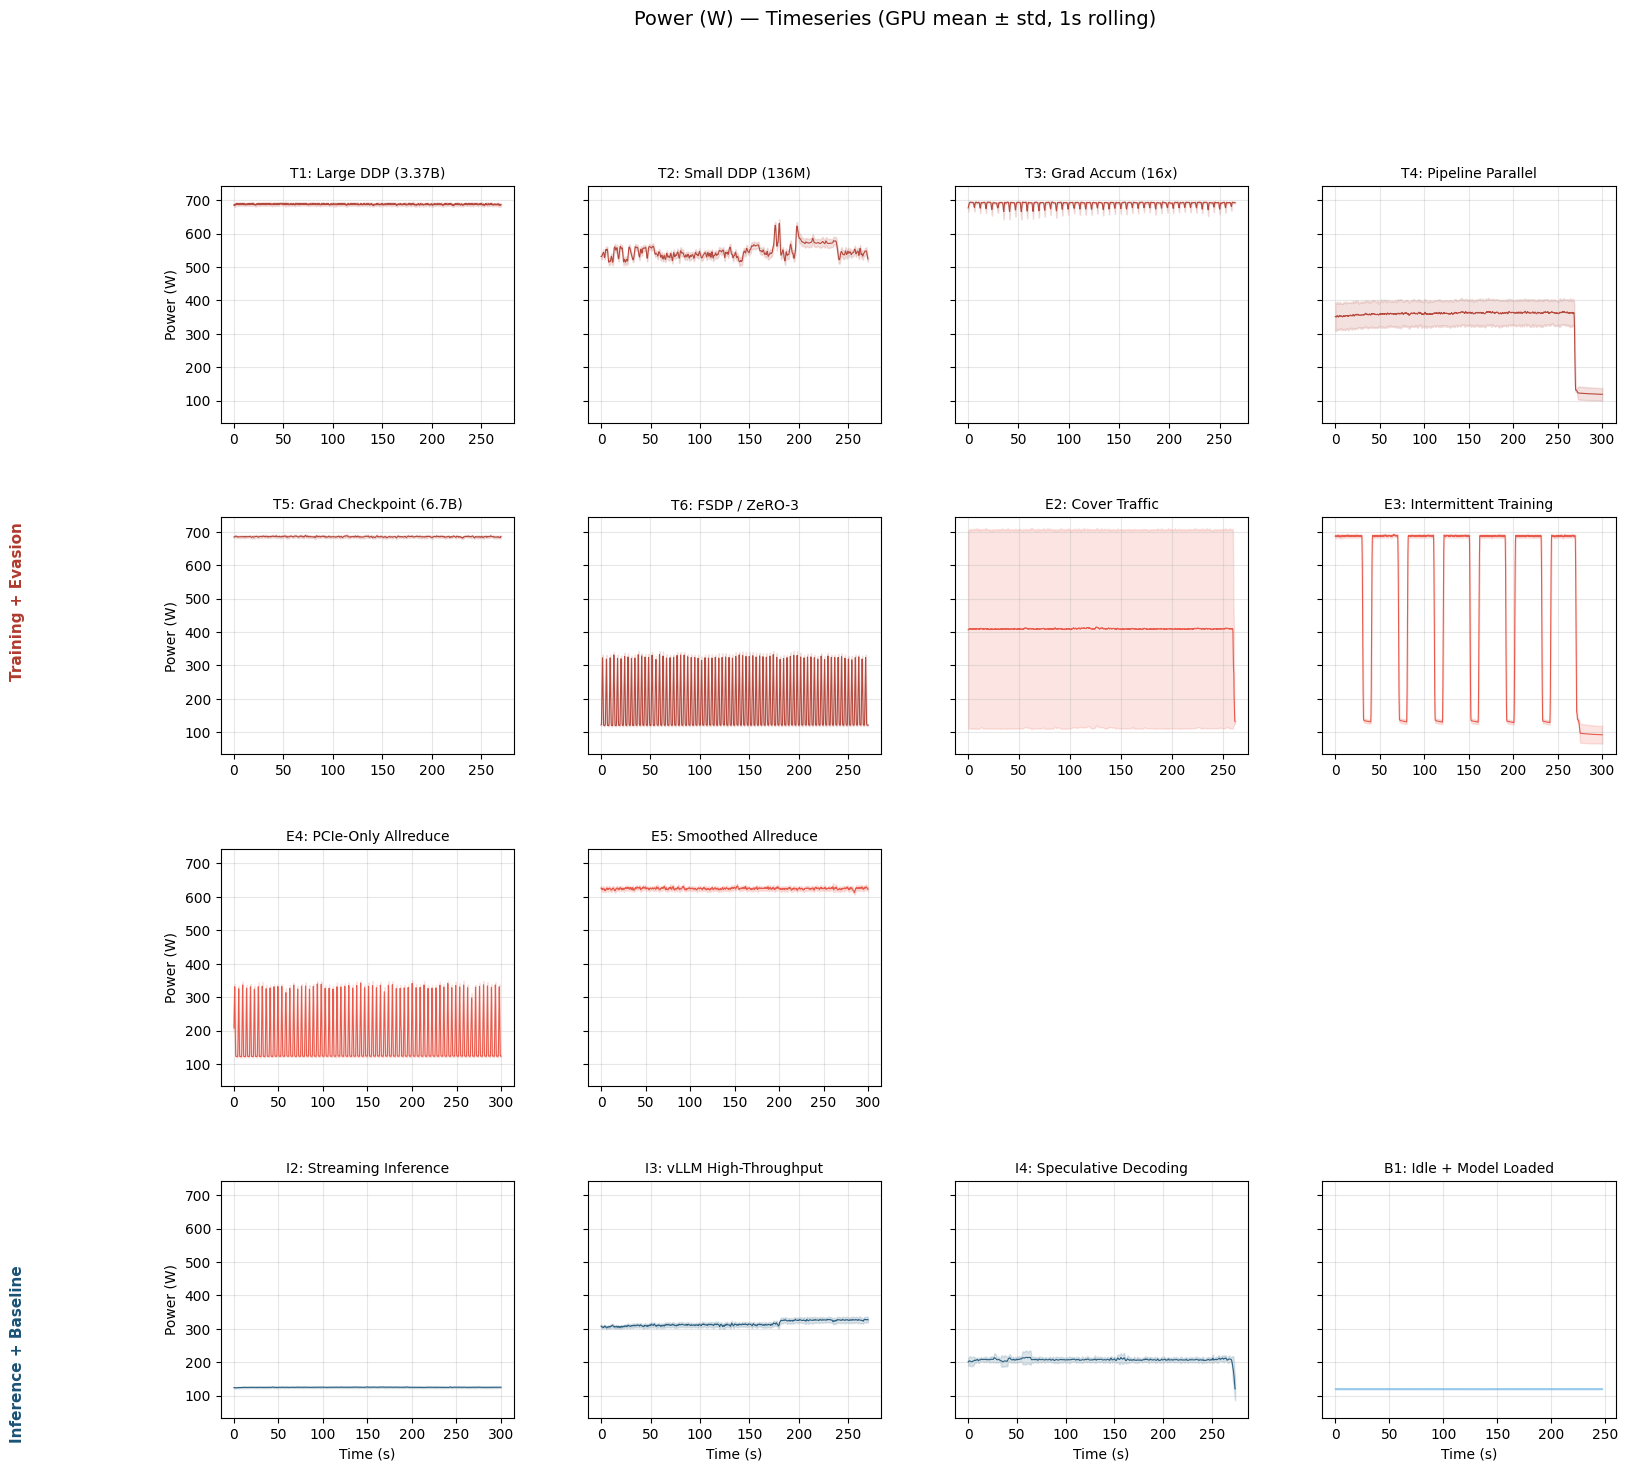

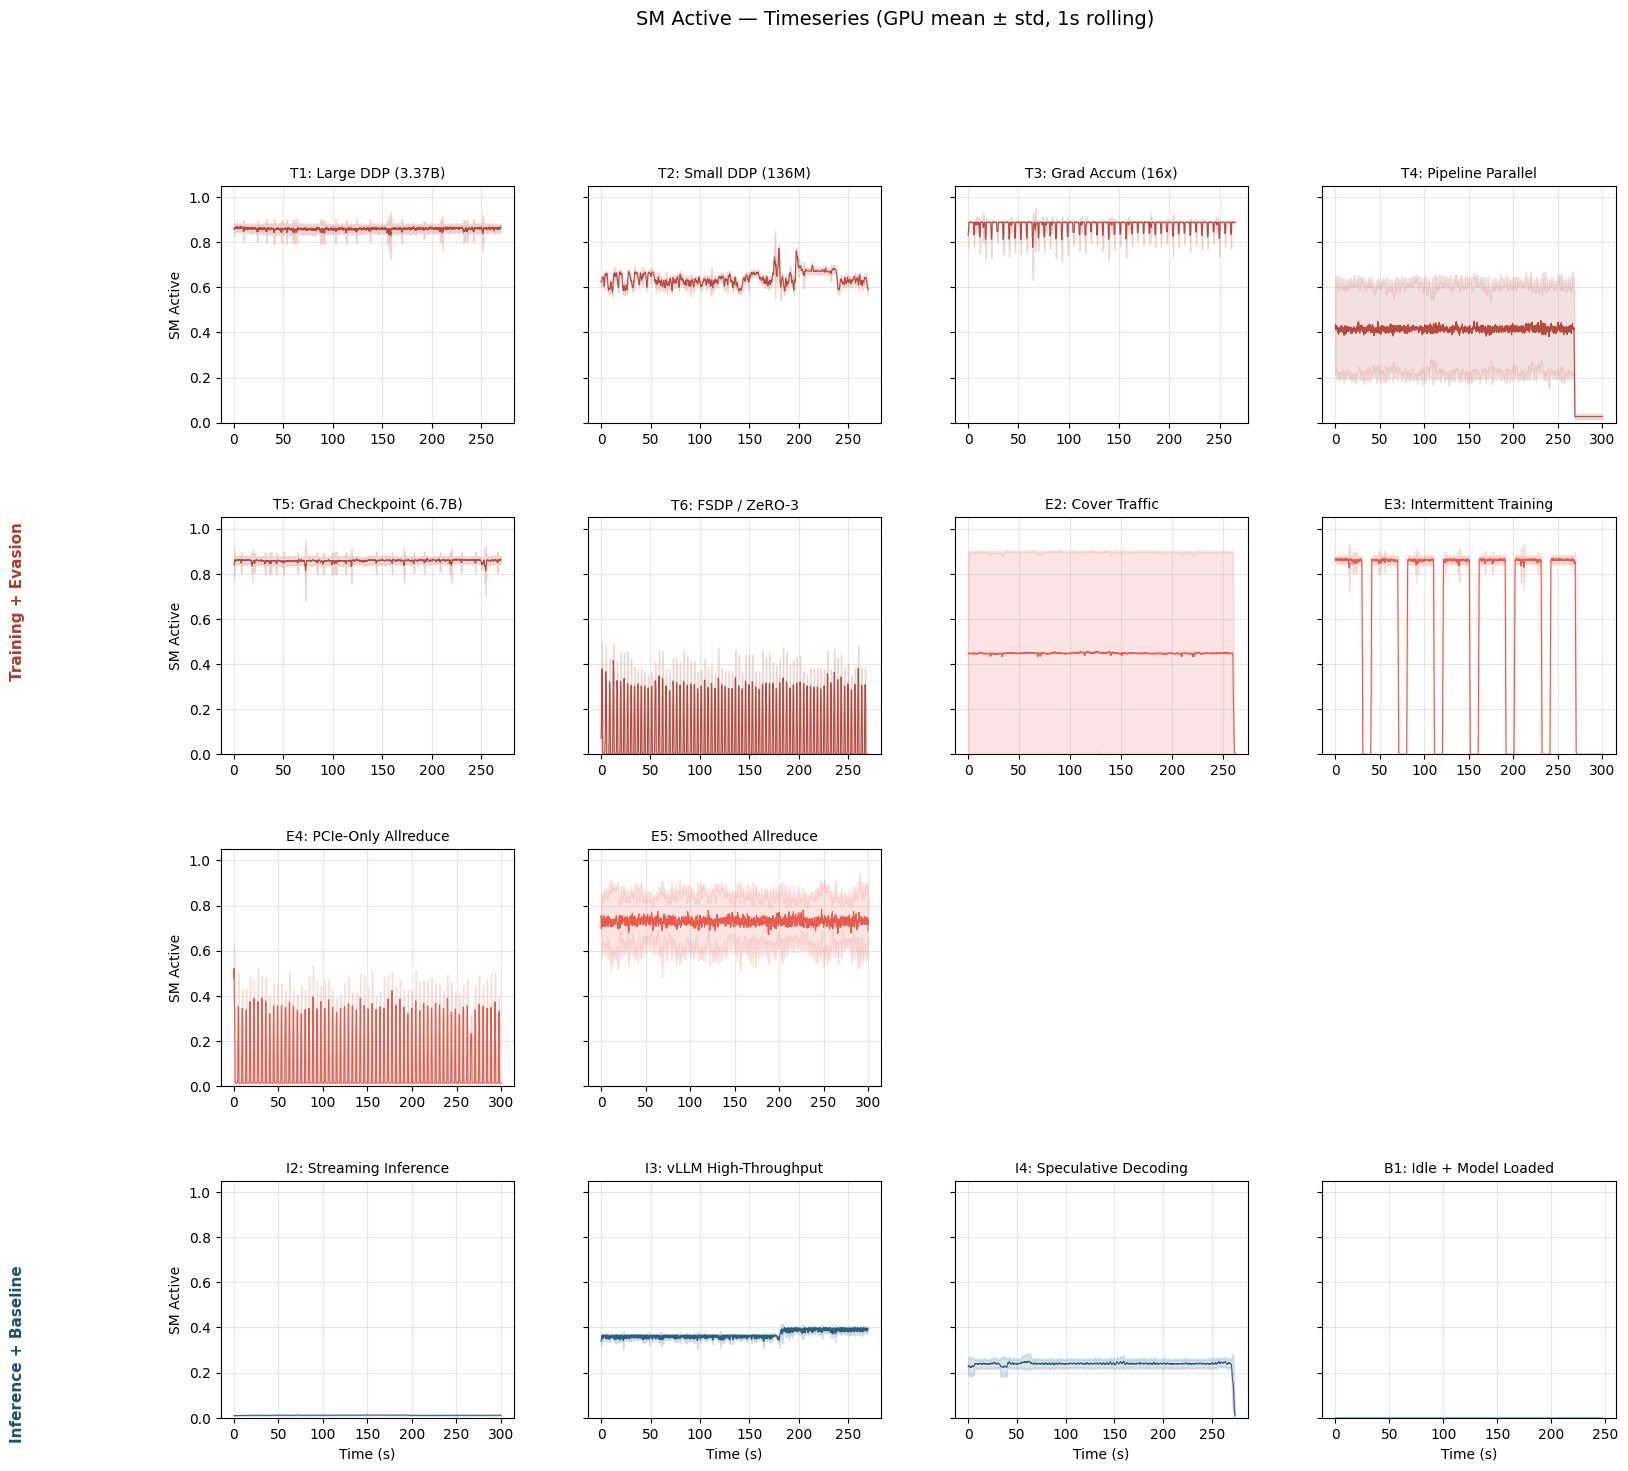

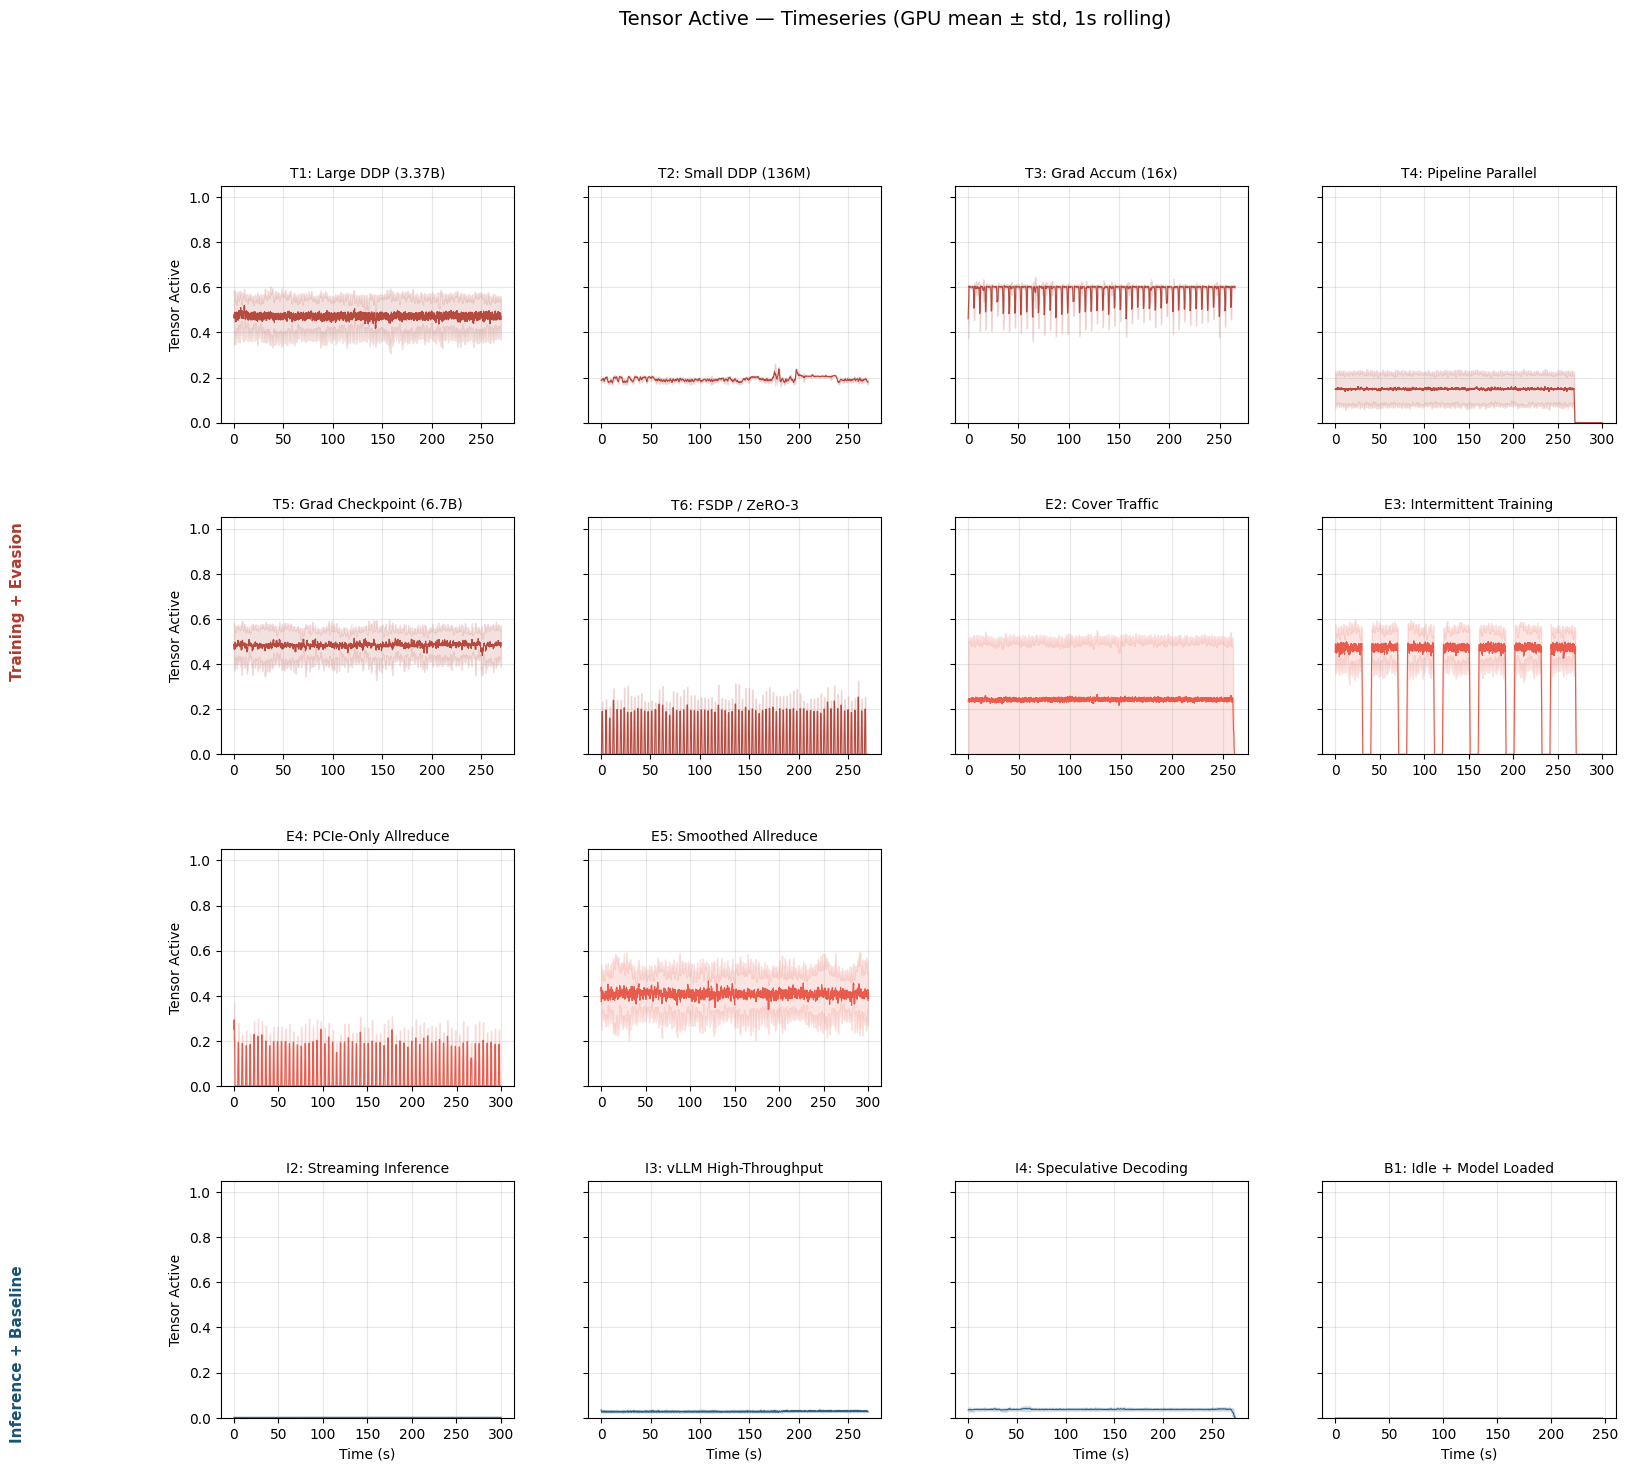

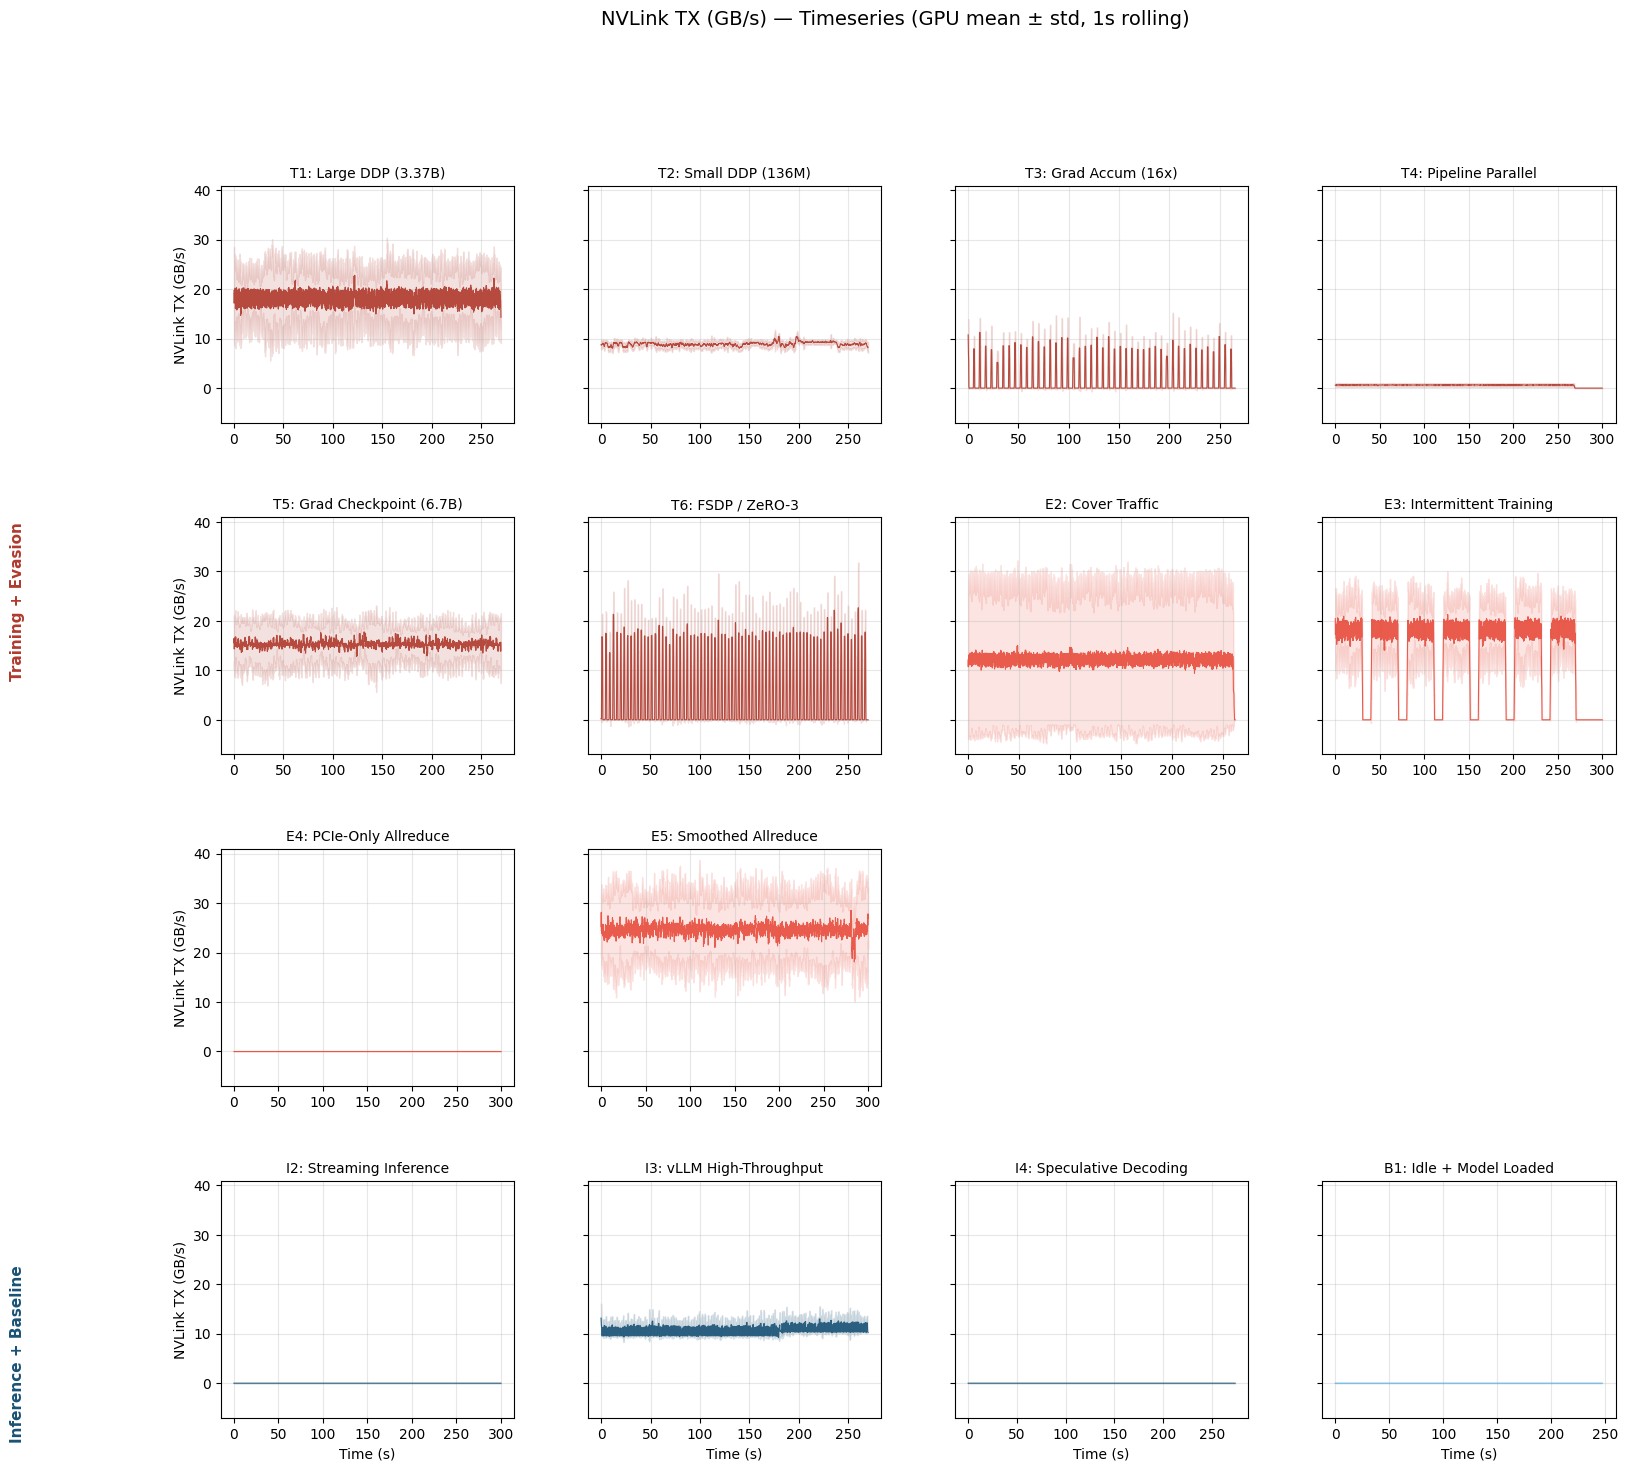

In [6]:
def _plot_single_ts(ax, code, signal_col):
    df = dfs[code].copy()
    df['time_bin'] = df['rel_time'].round(1)
    gm = df.groupby('time_bin')[signal_col].agg(['mean', 'std']).reset_index()
    gm['mean_s'] = gm['mean'].rolling(10, min_periods=1, center=True).mean()
    gm['std_s'] = gm['std'].rolling(10, min_periods=1, center=True).mean()
    color = COLORS[code]
    ax.plot(gm['time_bin'], gm['mean_s'], color=color, linewidth=0.8, alpha=0.9)
    ax.fill_between(gm['time_bin'],
                    gm['mean_s'] - gm['std_s'],
                    gm['mean_s'] + gm['std_s'],
                    color=color, alpha=0.15)
    ax.set_title(f'{code}: {CONDITIONS[code][1]}', fontsize=10)


def plot_two_section_ts(signal_col, ylabel, ylim=None, fname=None):
    n_top_rows = 3  # 10 conditions in TOP_ORDER → ceil(10/4) = 3
    n_total_rows = n_top_rows + 1  # +1 for bottom section
    fig = plt.figure(figsize=(18, 4 * n_total_rows))
    gs = fig.add_gridspec(n_total_rows, 4, hspace=0.4, wspace=0.25)
    first_ax = None

    for i, code in enumerate(TOP_ORDER):
        if code not in dfs:
            continue
        row, col = divmod(i, 4)
        ax = fig.add_subplot(gs[row, col], sharey=first_ax)
        if first_ax is None:
            first_ax = ax
        _plot_single_ts(ax, code, signal_col)
        if col > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
        else:
            ax.set_ylabel(ylabel)

    # Hide unused cells in last top row
    n_top = len([c for c in TOP_ORDER if c in dfs])
    for j in range(n_top, n_top_rows * 4):
        row, col = divmod(j, 4)
        fig.add_subplot(gs[row, col]).set_visible(False)

    for i, code in enumerate(BOT_ORDER):
        if code not in dfs:
            continue
        ax = fig.add_subplot(gs[n_top_rows, i], sharey=first_ax)
        _plot_single_ts(ax, code, signal_col)
        ax.set_xlabel('Time (s)')
        if i > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
        else:
            ax.set_ylabel(ylabel)

    if ylim:
        first_ax.set_ylim(ylim)

    fig.text(0.008, 0.62, 'Training + Evasion', fontsize=11, fontweight='bold',
             va='center', rotation=90, color=SHADE['Training'])
    fig.text(0.008, 0.15, 'Inference + Baseline', fontsize=11, fontweight='bold',
             va='center', rotation=90, color=SHADE['Inference'])

    fig.suptitle(f'{ylabel} — Timeseries (GPU mean ± std, 1s rolling)',
                 fontsize=14, y=0.99)
    fig.tight_layout(rect=[0.025, 0, 1, 0.97])
    if fname:
        fig.savefig(PLOT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_two_section_ts('power_w', 'Power (W)', fname='02_timeseries_power.png')
plot_two_section_ts('sm_active', 'SM Active', ylim=(0, 1.05), fname='03_timeseries_sm_active.png')
plot_two_section_ts('tensor_active', 'Tensor Active', ylim=(0, 1.05), fname='04_timeseries_tensor_active.png')
plot_two_section_ts('nvlink_tx_gb_s', 'NVLink TX (GB/s)', fname='05_timeseries_nvlink_tx.png')

## 3. GPU \u00d7 Time Heatmaps
Shared color scale across all conditions. Shows the allreduce heartbeat (synchronized vertical striping in training).

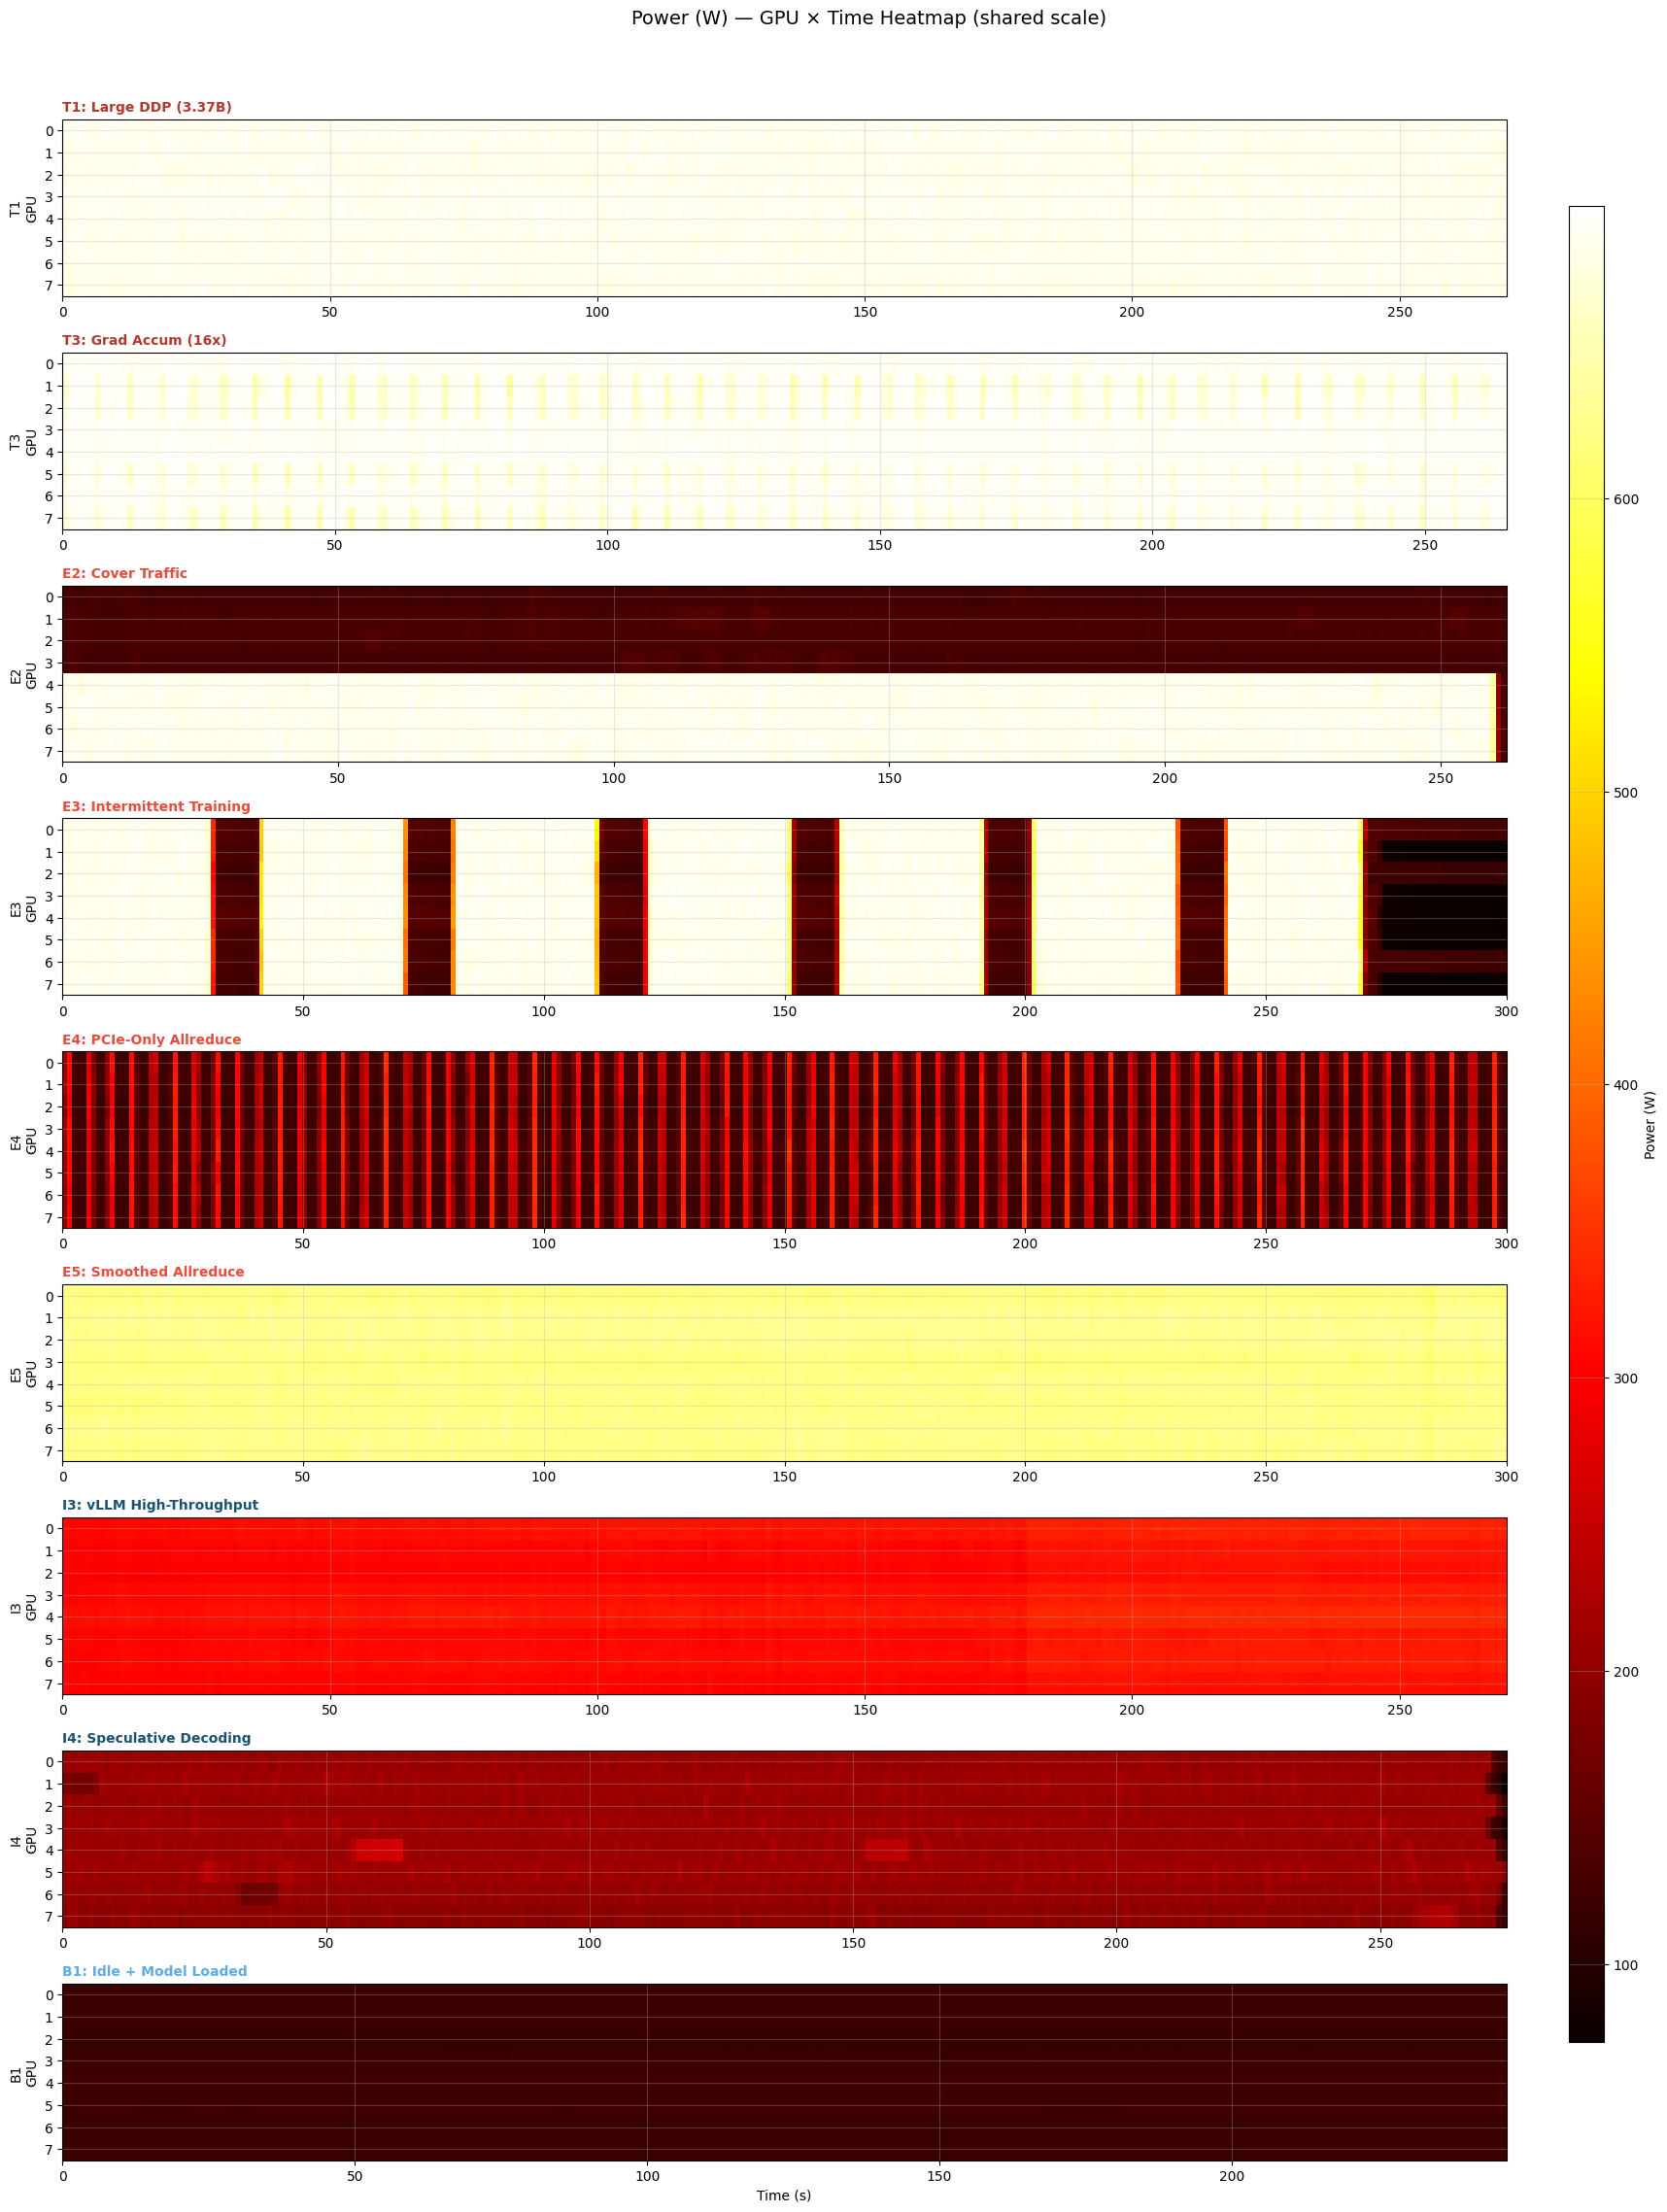

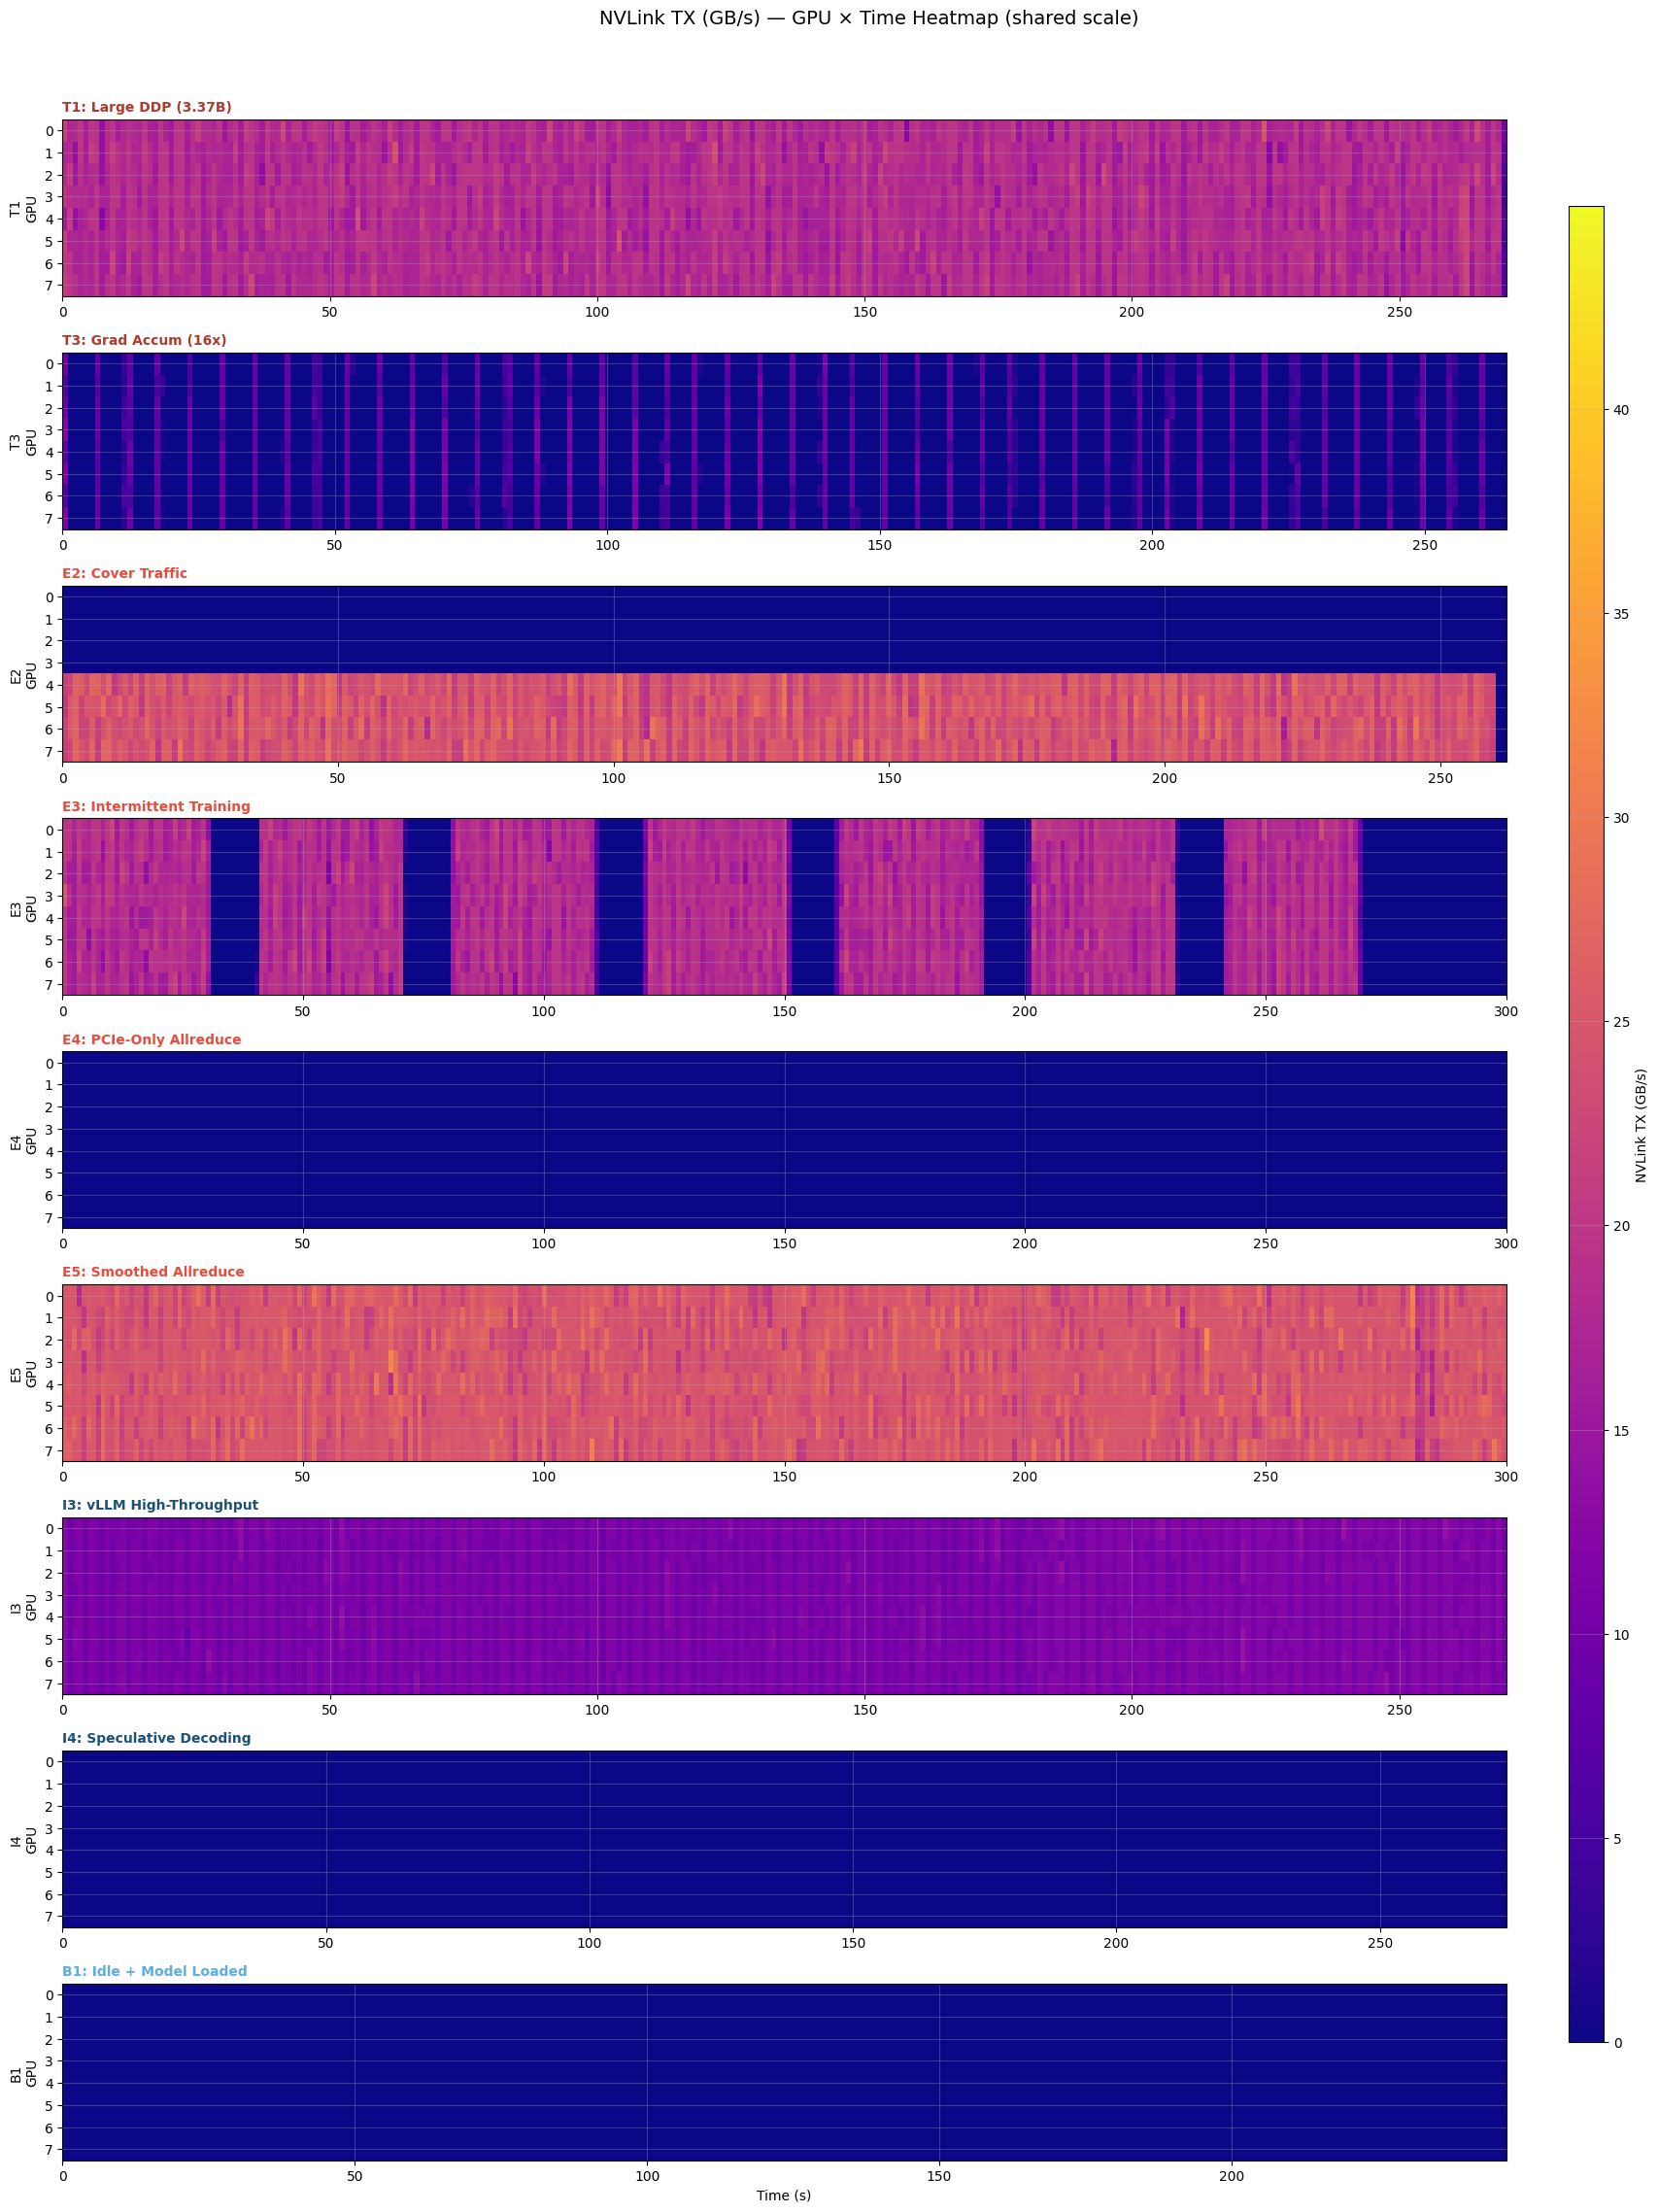

In [7]:
HEATMAP_CONDITIONS = ['T1', 'T3', 'E2', 'E3', 'E4', 'E5', 'I3', 'I4', 'B1']

def plot_heatmap_grid(signal_col, ylabel, cmap='viridis', fname=None):
    codes = [c for c in HEATMAP_CONDITIONS if c in dfs]
    vmin = min(dfs[c][signal_col].quantile(0.01) for c in codes)
    vmax = max(dfs[c][signal_col].quantile(0.99) for c in codes)

    fig, axes = plt.subplots(len(codes), 1, figsize=(18, 2.5 * len(codes)))
    if len(codes) == 1:
        axes = [axes]

    for ax, code in zip(axes, codes):
        df = dfs[code].copy()
        df['time_1s'] = df['rel_time'].round(0).astype(int)
        pivot = df.pivot_table(index='gpu', columns='time_1s',
                               values=signal_col, aggfunc='mean').sort_index()
        im = ax.imshow(pivot.values, aspect='auto', cmap=cmap,
                       extent=[pivot.columns.min(), pivot.columns.max(), 7.5, -0.5],
                       vmin=vmin, vmax=vmax)
        ax.set_ylabel(f'{code}\nGPU')
        ax.set_yticks(range(8))
        ax.set_xlabel('Time (s)' if code == codes[-1] else '')
        cat = CONDITIONS[code][2]
        ax.set_title(f'{code}: {CONDITIONS[code][1]}', fontsize=10,
                     loc='left', color=SHADE[cat], fontweight='bold')

    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.08, 0.02, 0.84])
    fig.colorbar(im, cax=cbar_ax, label=ylabel)

    fig.suptitle(f'{ylabel} — GPU × Time Heatmap (shared scale)', fontsize=14, y=1.01)
    fig.tight_layout(rect=[0, 0, 0.88, 0.99])
    if fname:
        fig.savefig(PLOT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_heatmap_grid('power_w', 'Power (W)', cmap='hot', fname='06_heatmap_power.png')
plot_heatmap_grid('nvlink_tx_gb_s', 'NVLink TX (GB/s)', cmap='plasma', fname='07_heatmap_nvlink_tx.png')

## 4. Cross-GPU Synchrony
Std dev of power across 8 GPUs at each timestamp. Periodic spikes = synchronized allreduce.

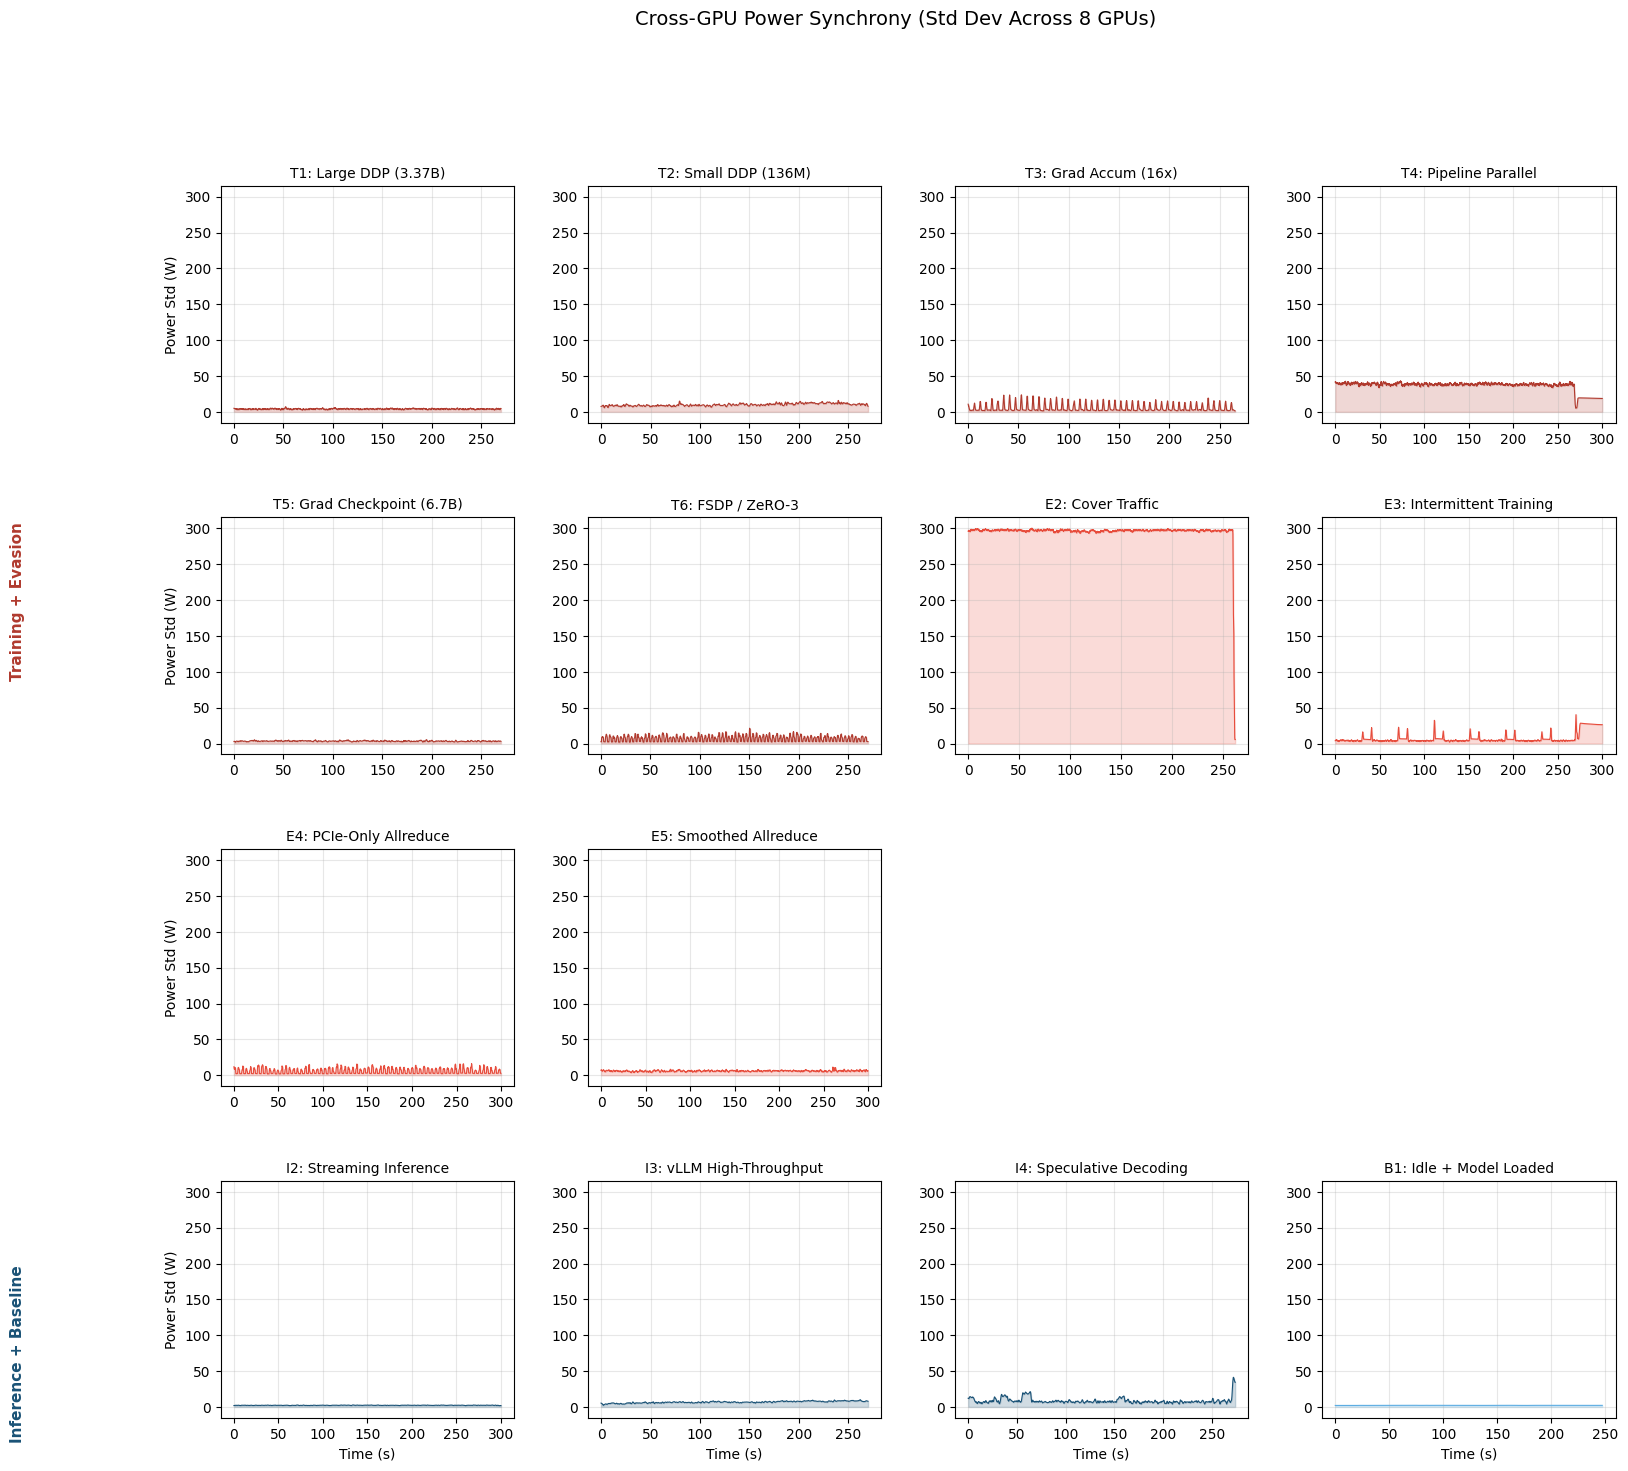

In [8]:
def _plot_sync(ax, code):
    df = dfs[code].copy()
    df['time_bin'] = df['rel_time'].round(1)
    cs = df.groupby('time_bin')['power_w'].std().reset_index()
    cs.columns = ['time', 'power_std']
    cs['smooth'] = cs['power_std'].rolling(10, min_periods=1, center=True).mean()
    color = COLORS[code]
    ax.plot(cs['time'], cs['smooth'], color=color, linewidth=0.8)
    ax.fill_between(cs['time'], 0, cs['smooth'], color=color, alpha=0.2)
    ax.set_title(f'{code}: {CONDITIONS[code][1]}', fontsize=10)


n_top_rows = 3
n_total_rows = n_top_rows + 1
fig = plt.figure(figsize=(18, 4 * n_total_rows))
gs = fig.add_gridspec(n_total_rows, 4, hspace=0.4, wspace=0.25)
first_ax = None

for i, code in enumerate(TOP_ORDER):
    if code not in dfs:
        continue
    row, col = divmod(i, 4)
    ax = fig.add_subplot(gs[row, col], sharey=first_ax)
    if first_ax is None:
        first_ax = ax
    _plot_sync(ax, code)
    if col == 0:
        ax.set_ylabel('Power Std (W)')

# Hide unused cells in last top row
n_top = len([c for c in TOP_ORDER if c in dfs])
for j in range(n_top, n_top_rows * 4):
    row, col = divmod(j, 4)
    fig.add_subplot(gs[row, col]).set_visible(False)

for i, code in enumerate(BOT_ORDER):
    if code not in dfs:
        continue
    ax = fig.add_subplot(gs[n_top_rows, i], sharey=first_ax)
    _plot_sync(ax, code)
    ax.set_xlabel('Time (s)')
    if i == 0:
        ax.set_ylabel('Power Std (W)')

fig.text(0.008, 0.62, 'Training + Evasion', fontsize=11, fontweight='bold',
         va='center', rotation=90, color=SHADE['Training'])
fig.text(0.008, 0.15, 'Inference + Baseline', fontsize=11, fontweight='bold',
         va='center', rotation=90, color=SHADE['Inference'])

fig.suptitle('Cross-GPU Power Synchrony (Std Dev Across 8 GPUs)', fontsize=14, y=0.99)
fig.tight_layout(rect=[0.025, 0, 1, 0.97])
fig.savefig(PLOT_DIR / '08_cross_gpu_synchrony.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tensor Core Analysis
`tensor_active / sm_active` — training hammers tensor cores. Is this ratio a standalone classifier?

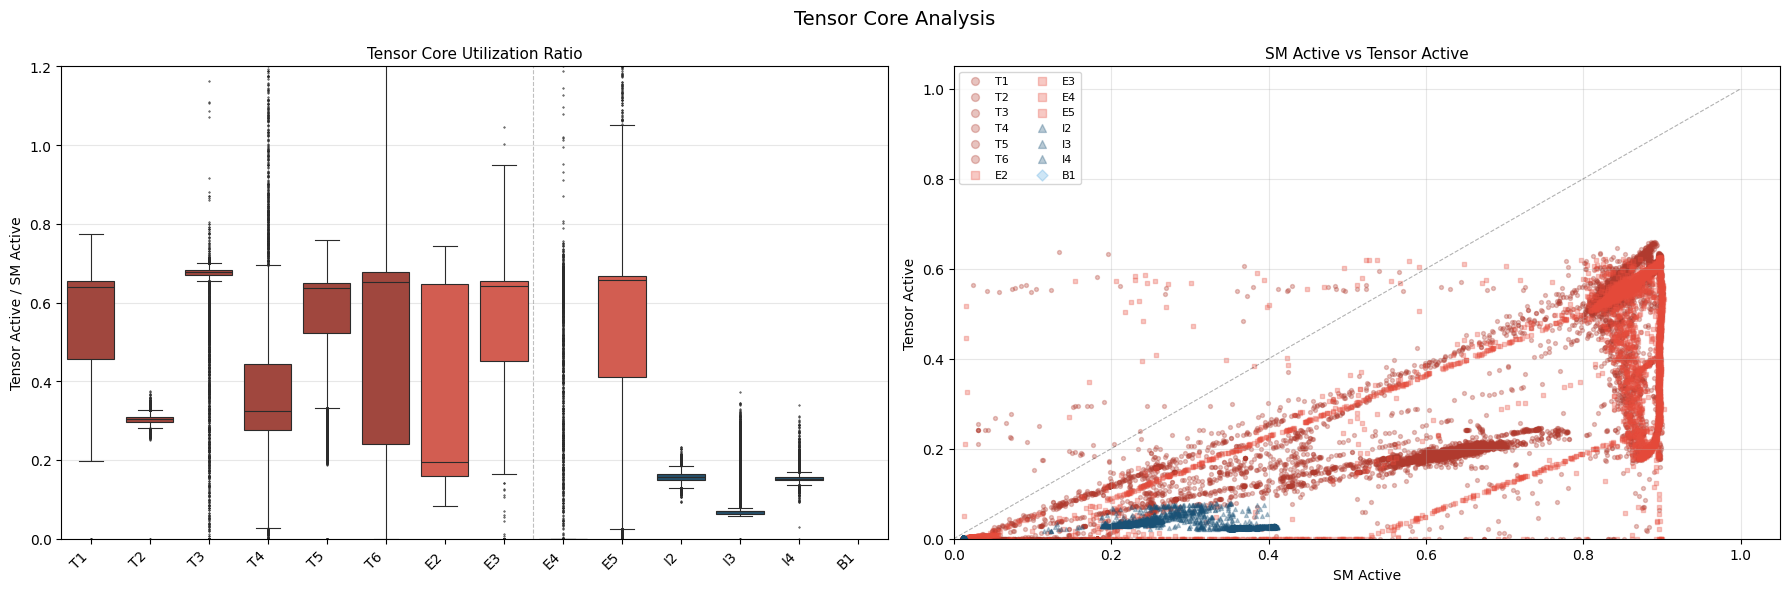

In [9]:
all_data['tensor_sm_ratio'] = np.where(
    all_data['sm_active'] > 0.01,
    all_data['tensor_active'] / all_data['sm_active'],
    np.nan
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

palette = {code: COLORS[code] for code in CONDITION_ORDER if code in dfs}
sns.boxplot(data=all_data, x='condition', y='tensor_sm_ratio', order=CONDITION_ORDER,
            palette=palette, ax=ax1, fliersize=0.5, linewidth=0.8)
ax1.set_ylabel('Tensor Active / SM Active')
ax1.set_xlabel('')
ax1.set_ylim(0, 1.2)
ax1.set_title('Tensor Core Utilization Ratio')
ax1.set_xticklabels(CONDITION_ORDER, rotation=45, ha='right')
ax1.axvline(x=7.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

# Scatter with different markers per category
markers = {'Training': 'o', 'Evasion': 's', 'Inference': '^', 'Baseline': 'D'}
sample = pd.concat([
    g.sample(min(2000, len(g)), random_state=42)
    for _, g in all_data.dropna(subset=['tensor_sm_ratio']).groupby('condition')
], ignore_index=True)

for code in CONDITION_ORDER:
    if code not in dfs:
        continue
    sub = sample[sample['condition'] == code]
    cat = CONDITIONS[code][2]
    ax2.scatter(sub['sm_active'], sub['tensor_active'],
               c=COLORS[code], alpha=0.3, s=8, marker=markers[cat], label=code)

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
ax2.set_xlabel('SM Active')
ax2.set_ylabel('Tensor Active')
ax2.set_xlim(0, 1.05)
ax2.set_ylim(0, 1.05)
ax2.set_title('SM Active vs Tensor Active')
ax2.legend(fontsize=8, markerscale=2, loc='upper left', ncol=2)

fig.suptitle('Tensor Core Analysis', fontsize=14)
fig.tight_layout()
fig.savefig(PLOT_DIR / '09_tensor_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. NVLink TX vs RX Symmetry
All conditions on one scatter. Training allreduce is symmetric (tight diagonal). Inset zooms into inference + baseline near the origin.

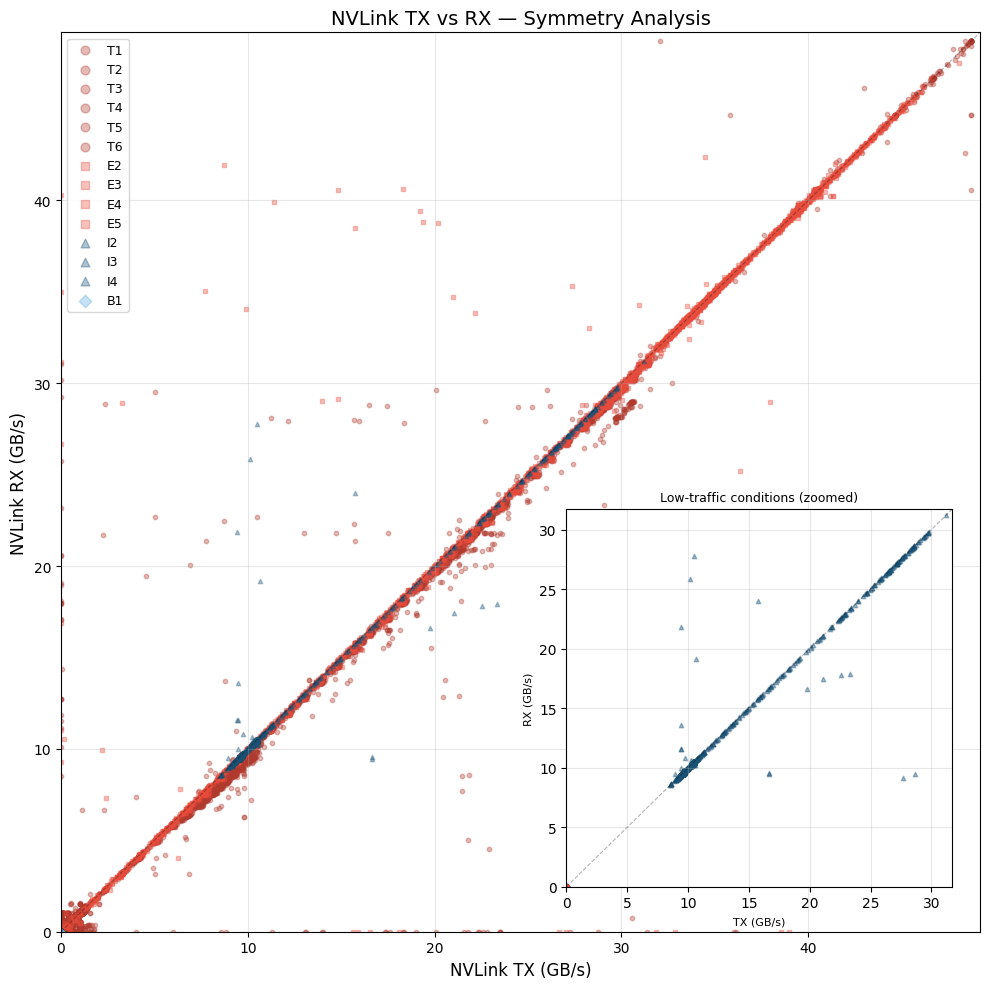

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

markers = {'Training': 'o', 'Evasion': 's', 'Inference': '^', 'Baseline': 'D'}

for code in CONDITION_ORDER:
    if code not in dfs:
        continue
    df = dfs[code]
    sub = df.sample(min(2000, len(df)), random_state=42)
    cat = CONDITIONS[code][2]
    ax.scatter(sub['nvlink_tx_gb_s'], sub['nvlink_rx_gb_s'],
               c=COLORS[code], alpha=0.35, s=10, marker=markers[cat], label=code)

lim = all_data['nvlink_tx_gb_s'].quantile(0.995) * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=0.8)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('NVLink TX (GB/s)', fontsize=12)
ax.set_ylabel('NVLink RX (GB/s)', fontsize=12)
ax.set_title('NVLink TX vs RX — Symmetry Analysis', fontsize=14)
ax.legend(fontsize=9, markerscale=2, loc='upper left')

# Inset: zoom into inference + baseline near origin
axins = ax.inset_axes([0.55, 0.05, 0.42, 0.42])
for code in ['I2', 'I3', 'I4', 'B1', 'E4']:
    if code not in dfs:
        continue
    df = dfs[code]
    sub = df.sample(min(2000, len(df)), random_state=42)
    cat = CONDITIONS[code][2]
    axins.scatter(sub['nvlink_tx_gb_s'], sub['nvlink_rx_gb_s'],
                  c=COLORS[code], alpha=0.4, s=10, marker=markers[cat])
low_lim = max(
    all_data[all_data['category'].isin(['Inference', 'Baseline'])]['nvlink_tx_gb_s'].quantile(0.99),
    dfs.get('E4', pd.DataFrame({'nvlink_tx_gb_s': [0.1]}))['nvlink_tx_gb_s'].quantile(0.99),
    0.1
) * 1.3
axins.plot([0, low_lim], [0, low_lim], 'k--', alpha=0.3, linewidth=0.8)
axins.set_xlim(0, low_lim)
axins.set_ylim(0, low_lim)
axins.set_title('Low-traffic conditions (zoomed)', fontsize=9)
axins.set_xlabel('TX (GB/s)', fontsize=8)
axins.set_ylabel('RX (GB/s)', fontsize=8)

fig.tight_layout()
fig.savefig(PLOT_DIR / '10_nvlink_symmetry.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Signal Correlation Structure
Per-condition correlation matrix of key signals. Training should show tight coupling between power/SM/tensor; inference less so.

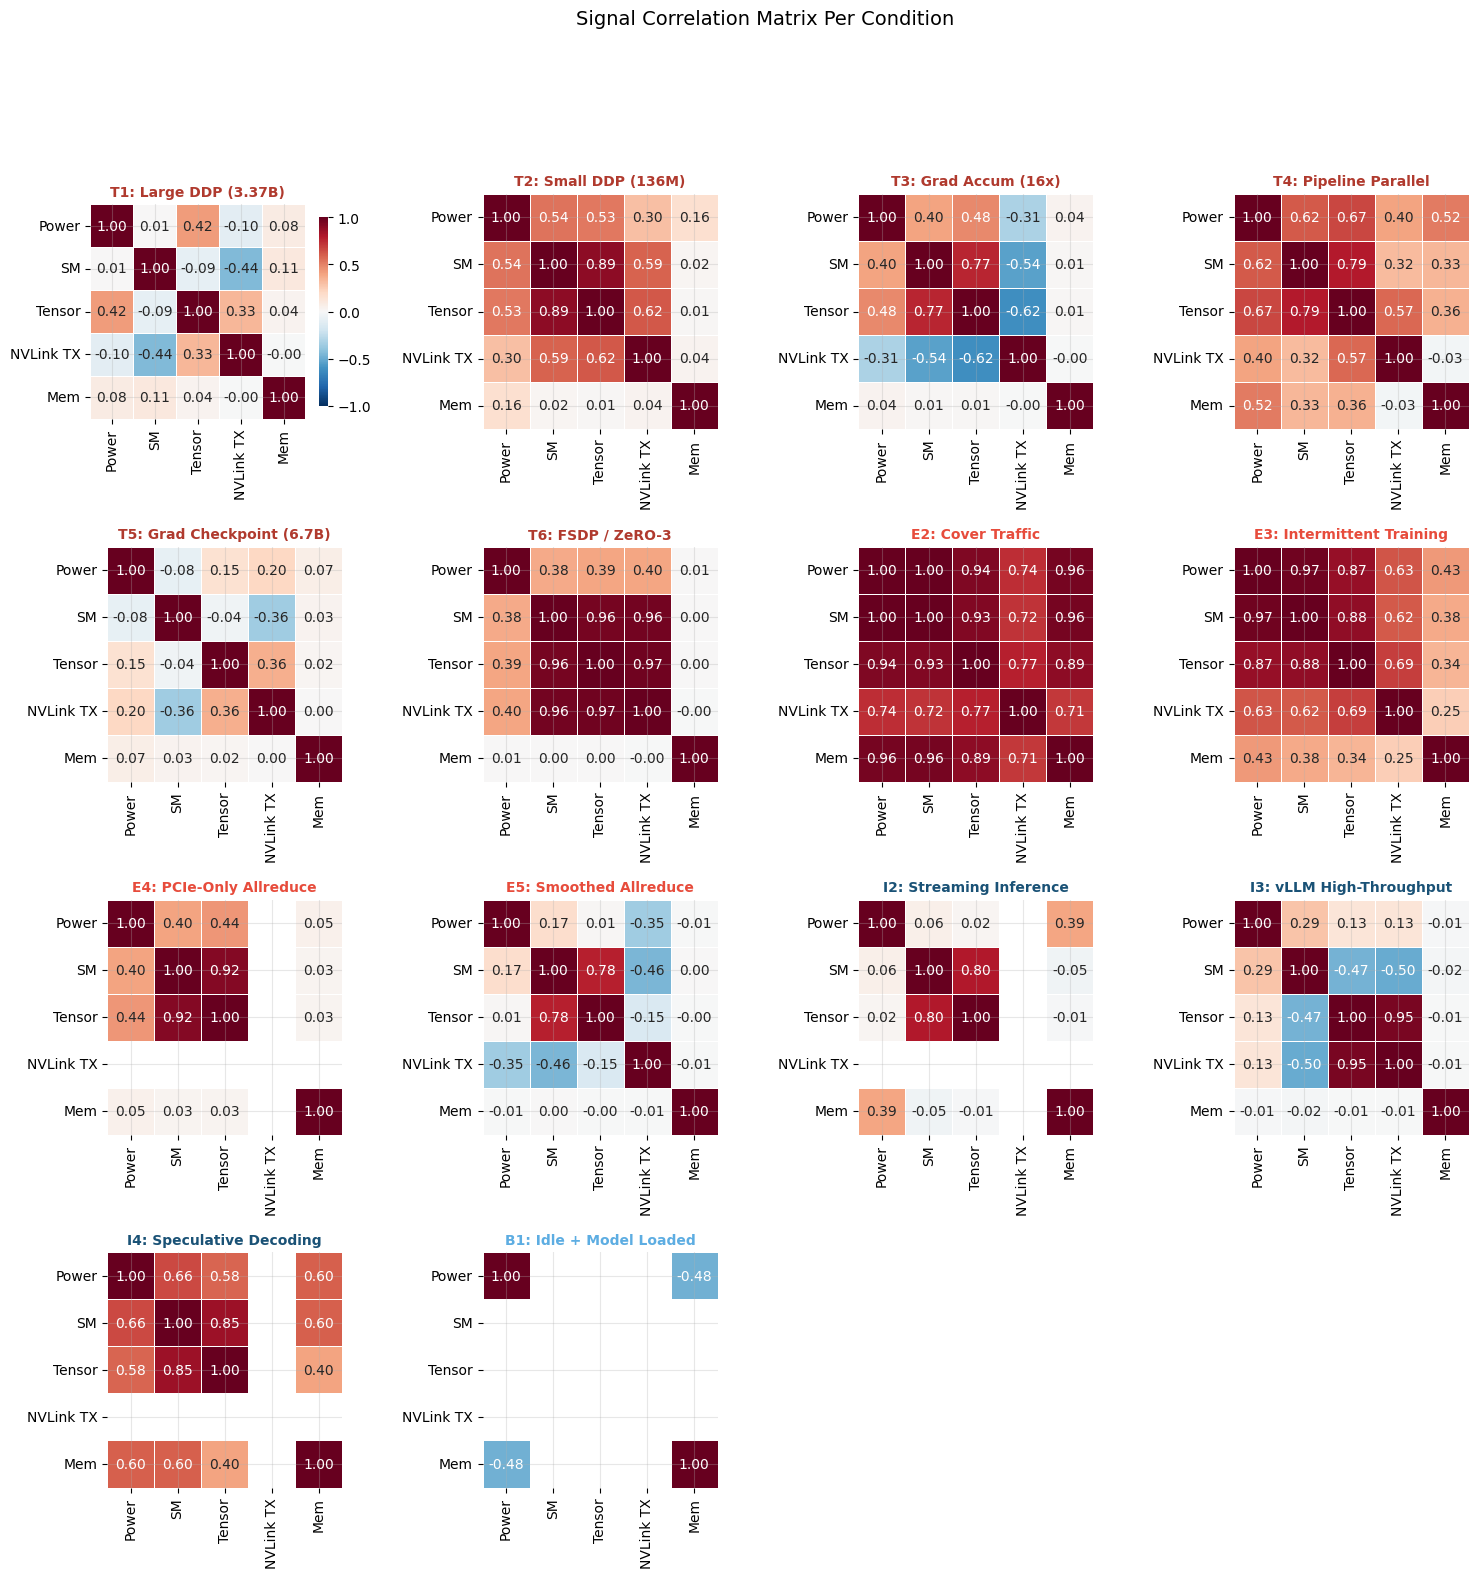

In [11]:
corr_cols = ['power_w', 'sm_active', 'tensor_active', 'nvlink_tx_gb_s', 'mem_used_gib']
corr_labels = ['Power', 'SM', 'Tensor', 'NVLink TX', 'Mem']

n_cols = 4
codes = [c for c in CONDITION_ORDER if c in dfs]
n_rows = -(-len(codes) // n_cols)  # ceil division

fig = plt.figure(figsize=(18, 4.2 * n_rows))
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.5, wspace=0.4)

for i, code in enumerate(codes):
    row, col = divmod(i, n_cols)
    ax = fig.add_subplot(gs[row, col])
    corr = dfs[code][corr_cols].corr()
    sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, center=0, cmap='RdBu_r',
                annot=True, fmt='.2f', square=True, linewidths=0.5,
                xticklabels=corr_labels, yticklabels=corr_labels,
                cbar=i == 0, cbar_kws={'shrink': 0.8} if i == 0 else {})
    cat = CONDITIONS[code][2]
    ax.set_title(f'{code}: {CONDITIONS[code][1]}', fontsize=10,
                 color=SHADE[cat], fontweight='bold')

# Hide unused subplots
for j in range(len(codes), n_rows * n_cols):
    r, c = divmod(j, n_cols)
    fig.add_subplot(gs[r, c]).set_visible(False)

fig.suptitle('Signal Correlation Matrix Per Condition', fontsize=14, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(PLOT_DIR / '11_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
Plots saved to `../plots/`.